<a href="https://colab.research.google.com/github/henryparfait/Time-Series-Forecasting/blob/main/notebooks/03_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting experiments: SARIMAX + Fourier, LSTM, TCN



In [1]:
# ---- 1. Setup --------------------------------------------------------------------------------
import os, json, time, platform, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, psutil
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from google.colab import drive
drive.mount('/content/drive')
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_DIR = Path('/content/drive/MyDrive/milan_forecasting')
PROC_DIR, FIG_DIR, RES_DIR = PROJECT_DIR / 'processed', PROJECT_DIR / 'figures', PROJECT_DIR / 'results'
for d in (FIG_DIR, RES_DIR): d.mkdir(parents=True, exist_ok=True)
SEED, EPOCHS = 42, 60
MODELS = ['SARIMAX', 'LSTM', 'TCN']
BASELINES = ['Persistence', 'Seasonal naive (1 week)']
COLORS = {'SARIMAX': '#2e86c1', 'LSTM': '#c0392b', 'TCN': '#27ae60'}

def gpu_name():
    try:
        return subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total',
                                        '--format=csv,noheader']).decode().strip()
    except Exception:
        return 'none'
HARDWARE = {'platform': platform.platform(), 'cpu': platform.processor(), 'logical_cpus': psutil.cpu_count(),
            'ram_gb': round(psutil.virtual_memory().total / 1e9, 1), 'gpu': gpu_name(),
            'python': platform.python_version(), 'tensorflow': tf.__version__,
            'keras': keras.__version__, 'statsmodels': statsmodels.__version__}
print(HARDWARE)
if HARDWARE['gpu'] == 'none':
    print('WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU (CPU works but is much slower).')
(RES_DIR / 'hardware.json').write_text(json.dumps(HARDWARE, indent=1))

# ---- data (only the small CSV exported by notebook 01) ----
raw = pd.read_csv(PROC_DIR / 'selected_series.csv', index_col=0)
raw.index = pd.to_datetime(raw.index, utc=True).tz_convert('Europe/Rome').tz_localize(None)
TIME = raw.index
sel_info = json.load(open(PROC_DIR / 'selected_squares.json'))
TOP3 = sel_info['top3']; TOP = TOP3[0]
EXTRA = [s for s in sel_info['selected'] if s not in TOP3]

i_val, i_test, i_end = [int(np.searchsorted(TIME, pd.Timestamp(t))) for t in ('2013-12-09', '2013-12-16', '2013-12-23')]
assert (i_val, i_test, i_end) == (5472, 6480, 7488), (i_val, i_test, i_end)
IDX = {'train': np.arange(0, i_val), 'val': np.arange(i_val, i_test), 'test': np.arange(i_test, i_end)}

# ---- calendar features (known in advance, so legitimate inputs) ----
HOLIDAYS = pd.to_datetime(['2013-11-01', '2013-12-07', '2013-12-08'])   # All Saints, Sant'Ambrogio, Immacolata
slot = np.asarray(TIME.hour * 6 + TIME.minute // 10)
dow = np.asarray(TIME.dayofweek)
offday = ((dow >= 5) | np.asarray(TIME.normalize().isin(HOLIDAYS))).astype(float)
CAL = np.column_stack([np.sin(2 * np.pi * slot / 144), np.cos(2 * np.pi * slot / 144),
                       np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7), offday]).astype(np.float32)
t_all = np.arange(len(TIME))

def prepare(sq):
    y = raw[f'sq_{sq}'].to_numpy(dtype=float)
    ly = np.log1p(y)
    lo, hi = ly[IDX['train']].min(), ly[IDX['train']].max()        # fitted on TRAIN only
    z = (ly - lo) / (hi - lo)
    return {'sq': sq, 'y': y, 'ly': ly, 'z': z, 'lo': lo, 'hi': hi,
            'inputs': np.column_stack([z, CAL]).astype(np.float32)}

def inv_scale(d, zhat):
    return np.expm1(np.asarray(zhat) * (d['hi'] - d['lo']) + d['lo'])

def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float); e = p - y
    return {'MAE': float(np.mean(np.abs(e))), 'RMSE': float(np.sqrt(np.mean(e ** 2))),
            'MAPE_%': float(100 * np.mean(np.abs(e) / y)), 'WAPE_%': float(100 * np.abs(e).sum() / y.sum())}

print('Top-3:', TOP3, '| extra:', EXTRA, '| split idx:', i_val, i_test, i_end)

Mounted at /content/drive
{'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'cpu': 'x86_64', 'logical_cpus': 2, 'ram_gb': 13.6, 'gpu': 'Tesla T4, 15360 MiB', 'python': '3.13.15', 'tensorflow': '2.20.0', 'keras': '3.13.2', 'statsmodels': '0.15.0'}
Top-3: [5161, 5059, 5259] | extra: [4159, 4556] | split idx: 5472 6480 7488


## Model definitions

**SARIMAX + Fourier** (regression with ARMA errors): `log1p(x_t) = c + Σ Fourier(daily, K_d) + Σ Fourier(weekly, K_w) + β·offday + ARMA(p, q) errors`.
Seasonal ARIMA with s = 144 or s = 1008 is computationally impractical, so the two seasonalities are represented
by deterministic Fourier terms, and short-term dynamics by the ARMA part (d = 0, justified by the ADF/KPSS results).
Test predictions are one-step-ahead Kalman-filter predictions with **fixed** parameters (no refitting).

**LSTM:** window of *L* past steps × 6 features (scaled log traffic + 5 calendar features) → LSTM layer(s) → dropout → dense(1).

**TCN:** the same inputs → 1×1 projection → *n* residual blocks, each with two causal dilated Conv1D layers (dilation 1, 2, 4, …)
→ output at the last time step → dense(1). Receptive field = 1 + 2·(k−1)·(2ⁿ − 1).

In [2]:
# ---- 2. Models ---------------------------------------------------------------------------------
from numpy.lib.stride_tricks import sliding_window_view

def fourier(Kd, Kw):
    cols = []
    for k in range(1, Kd + 1):
        cols += [np.sin(2 * np.pi * k * t_all / 144), np.cos(2 * np.pi * k * t_all / 144)]
    for k in range(1, Kw + 1):
        cols += [np.sin(2 * np.pi * k * t_all / 1008), np.cos(2 * np.pi * k * t_all / 1008)]
    cols.append(offday)
    return np.column_stack(cols)

def run_sarimax(d, cfg, want_test=False):
    X, tr, va = fourier(cfg['K_daily'], cfg['K_weekly']), IDX['train'], IDX['val']
    t0 = time.perf_counter()
    res = SARIMAX(d['ly'][tr], exog=X[tr], order=(cfg['p'], 0, cfg['q']), trend='c').fit(disp=False, maxiter=200)
    train_s = time.perf_counter() - t0
    pv = res.append(d['ly'][va], exog=X[va]).predict(start=i_val, end=i_test - 1)   # fixed params
    out = {'pred_val': np.expm1(pv), 'train_s': train_s, 'n_params': int(len(res.params)),
           'epochs': np.nan, 'converged': bool(res.mle_retvals.get('converged', True)), 'aic': float(res.aic)}
    if want_test:
        seg, times = np.arange(i_val, i_end), []
        for _ in range(3):
            t0 = time.perf_counter()
            pt = res.append(d['ly'][seg], exog=X[seg]).predict(start=i_test, end=i_end - 1)
            times.append(time.perf_counter() - t0)
        out.update(pred_test=np.expm1(pt), infer_s=float(np.median(times)))
    return out

def windows(d, L, idx):
    sw = sliding_window_view(d['inputs'], (L, d['inputs'].shape[1]))[:, 0]   # sw[j] = inputs[j : j+L]
    return np.ascontiguousarray(sw[idx - L]), d['z'][idx].astype(np.float32)  # history strictly before target

def build_lstm(L, n_feat, cfg):
    inp = keras.Input((L, n_feat)); x = inp
    for i in range(cfg['layers']):
        x = keras.layers.LSTM(cfg['units'], return_sequences=i < cfg['layers'] - 1)(x)
        x = keras.layers.Dropout(cfg['dropout'])(x)
    return keras.Model(inp, keras.layers.Dense(1)(x), name='lstm')

def build_tcn(L, n_feat, cfg):
    f, k = cfg['filters'], cfg['kernel']
    inp = keras.Input((L, n_feat))
    x = keras.layers.Conv1D(f, 1)(inp)
    for i in range(cfg['levels']):
        h = keras.layers.Conv1D(f, k, padding='causal', dilation_rate=2 ** i, activation='relu')(x)
        h = keras.layers.Dropout(cfg['dropout'])(h)
        h = keras.layers.Conv1D(f, k, padding='causal', dilation_rate=2 ** i, activation='relu')(h)
        x = keras.layers.Add()([x, h])
    x = keras.layers.Lambda(lambda t: t[:, -1, :], output_shape=(f,))(x)
    return keras.Model(inp, keras.layers.Dense(1)(x), name='tcn')

def receptive_field(cfg): return 1 + 2 * (cfg['kernel'] - 1) * (2 ** cfg['levels'] - 1)

def run_nn(d, kind, cfg, want_test=False):
    L, resid = cfg['L'], cfg.get('residual', False)
    tr = IDX['train'][IDX['train'] >= L]
    Xtr, ytr = windows(d, L, tr); Xva, yva = windows(d, L, IDX['val'])
    if resid:   # learn the standardised CHANGE from the last observed value (persistence-corrected target)
        s = float((d['z'][tr] - d['z'][tr - 1]).std())
        to_t = lambda idx, zt: ((zt - d['z'][idx - 1]) / s).astype(np.float32)
        from_t = lambda idx, o: d['z'][idx - 1] + o * s
        ytr, yva = to_t(tr, ytr), to_t(IDX['val'], yva)
    else:
        from_t = lambda idx, o: o
    keras.backend.clear_session(); keras.utils.set_random_seed(cfg.get('seed', SEED))
    model = (build_lstm if kind == 'LSTM' else build_tcn)(L, Xtr.shape[2], cfg)
    model.compile(keras.optimizers.Adam(cfg['lr']), loss='mse')
    cbs = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)]
    t0 = time.perf_counter()
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=EPOCHS, batch_size=cfg['batch'],
                     shuffle=True, verbose=0, callbacks=cbs)
    train_s = time.perf_counter() - t0
    pv = from_t(IDX['val'], model.predict(Xva, batch_size=1024, verbose=0).ravel())
    out = {'pred_val': inv_scale(d, pv), 'train_s': train_s, 'n_params': int(model.count_params()),
           'epochs': len(hist.history['loss']), 'best_epoch': int(np.argmin(hist.history['val_loss']) + 1),
           'history': {k: [float(v) for v in vals] for k, vals in hist.history.items()}}
    if want_test:
        Xte, _ = windows(d, L, IDX['test'])
        model.predict(Xte[:256], batch_size=1024, verbose=0)            # warm-up (graph tracing)
        times = []
        for _ in range(5):
            t0 = time.perf_counter()
            pt = from_t(IDX['test'], model.predict(Xte, batch_size=1024, verbose=0).ravel())
            times.append(time.perf_counter() - t0)
        out.update(pred_test=inv_scale(d, pt), infer_s=float(np.median(times)))
    return out

def run(kind, d, cfg, want_test=False):
    return run_sarimax(d, cfg, want_test) if kind == 'SARIMAX' else run_nn(d, kind, cfg, want_test)

## Iterative hyperparameter tuning (on the highest-traffic square, validation week)
Each round tests one hypothesis motivated by the EDA or by the previous round. The best configuration so far
is carried forward, and only the parameter under study changes (coordinate-wise search). Every run is logged to
`results/experiment_log.csv`, and each round's decision to `results/tuning_decisions.json`.

In [3]:
# ---- 3. Tuning plan ---------------------------------------------------------------------------
TUNING = {
 'SARIMAX': {'base': {'p': 2, 'q': 0, 'K_daily': 6, 'K_weekly': 3}, 'rounds': [
   {'param': 'order', 'values': [(1, 0), (2, 0), (3, 0), (2, 1)],
    'why': 'PACF is dominated by lags 1-3: find the smallest ARMA order that captures short-term dependence'},
   {'param': 'K_daily', 'values': [4, 6, 10],
    'why': 'Daily seasonality is very strong (strength 0.94) and non-sinusoidal: test how many daily harmonics are needed'},
   {'param': 'K_weekly', 'values': [1, 3, 5],
    'why': 'Weekly strength 0.72 and ACF(1 week) > ACF(2-6 days): test how much weekly shape is needed'}]},
 'LSTM': {'base': {'L': 144, 'units': 64, 'layers': 1, 'dropout': 0.1, 'lr': 1e-3, 'batch': 128}, 'rounds': [
   {'param': 'L', 'values': [36, 144, 288],
    'why': 'PACF suggests short memory (6 h may suffice) but ACF peaks at 1 day: compare 6 h, 1 day, 2 days of context'},
   {'param': 'units', 'values': [32, 64, 128], 'why': 'Capacity: is the model under- or over-fitting?'},
   {'param': 'layers', 'values': [1, 2], 'why': 'Does a second recurrent layer add useful non-linear structure?'},
   {'param': 'lr', 'values': [3e-4, 1e-3, 3e-3], 'why': 'Optimisation: check sensitivity to the learning rate'}]},
 'TCN': {'base': {'L': 288, 'filters': 32, 'kernel': 3, 'levels': 6, 'dropout': 0.1, 'lr': 1e-3, 'batch': 128}, 'rounds': [
   {'param': 'levels', 'values': [4, 5, 6],
    'why': 'Receptive field 61 / 125 / 253 steps: must it cover a full daily cycle (144 steps)?'},
   {'param': 'filters', 'values': [16, 32, 64], 'why': 'Capacity (number of filters per layer)'},
   {'param': 'dropout', 'values': [0.0, 0.1, 0.2], 'why': 'Regularisation: is the model over-fitting the training weeks?'},
   {'param': 'lr', 'values': [3e-4, 1e-3, 3e-3], 'why': 'Optimisation: check sensitivity to the learning rate'}]},
}

def set_param(cfg, param, v):
    c = dict(cfg)
    if param == 'order': c['p'], c['q'] = v
    else: c[param] = v
    return c

LOG_PATH, DEC_PATH, BEST_PATH = RES_DIR / 'experiment_log.csv', RES_DIR / 'tuning_decisions.json', RES_DIR / 'best_configs.json'
LOG = pd.read_csv(LOG_PATH).to_dict('records') if LOG_PATH.exists() else []
DECISIONS = json.load(open(DEC_PATH)) if DEC_PATH.exists() else []
BEST = json.load(open(BEST_PATH)) if BEST_PATH.exists() else {}

def tune(kind, d):
    spec, cache = TUNING[kind], {}
    def evaluate(cfg, rnd, why):
        key = json.dumps(cfg, sort_keys=True)
        if key in cache: return cache[key]
        out = run(kind, d, cfg)
        m = metrics(d['y'][IDX['val']], out['pred_val'])
        rec = {'model': kind, 'square': d['sq'], 'round': rnd, 'hypothesis': why, 'config': key,
               **{f'val_{k}': round(v, 4) for k, v in m.items()}, 'train_s': round(out['train_s'], 1),
               'epochs': out.get('epochs'), 'best_epoch': out.get('best_epoch'), 'n_params': out['n_params'],
               'converged': out.get('converged')}
        LOG.append(rec); pd.DataFrame(LOG).to_csv(LOG_PATH, index=False)
        print(f"  [{kind} r{rnd}] {key} -> val RMSE {m['RMSE']:.1f}, MAPE {m['MAPE_%']:.2f}%, {out['train_s']:.0f}s")
        cache[key] = m['RMSE']; return m['RMSE']
    best = dict(spec['base'])
    best_score = evaluate(best, 0, 'baseline configuration')
    for r, rd in enumerate(spec['rounds'], 1):
        print(f"{kind} round {r}: {rd['why']}")
        scores = [(evaluate(set_param(best, rd['param'], v), r, rd['why']), v) for v in rd['values']]
        s, v = min(scores, key=lambda t: t[0])
        prev = best_score
        if s < best_score: best, best_score = set_param(best, rd['param'], v), s
        DECISIONS.append({'model': kind, 'round': r, 'param': rd['param'], 'hypothesis': rd['why'],
                          'tested': {str(vv): round(ss, 2) for ss, vv in scores},
                          'chosen': str(v) if s < prev else 'kept previous', 'best_val_rmse': round(best_score, 2)})
        json.dump(DECISIONS, open(DEC_PATH, 'w'), indent=1)
    return best

In [4]:
# ---- 4. Run tuning (skips models already tuned) ------------------------------------------------
d_top = prepare(TOP)
t_tune = time.perf_counter()
for kind in MODELS:
    if kind in BEST:
        print(kind, 'already tuned:', BEST[kind]); continue
    t0 = time.perf_counter()
    BEST[kind] = tune(kind, d_top)
    json.dump(BEST, open(BEST_PATH, 'w'), indent=1)
    print(f'==> {kind} best: {BEST[kind]}  ({(time.perf_counter() - t0) / 60:.1f} min)\n')
print(f'Tuning finished in {(time.perf_counter() - t_tune) / 60:.1f} min')
pd.DataFrame(DECISIONS)[['model', 'round', 'param', 'chosen', 'best_val_rmse']]

SARIMAX already tuned: {'p': 3, 'q': 0, 'K_daily': 4, 'K_weekly': 5}
LSTM already tuned: {'L': 36, 'units': 128, 'layers': 1, 'dropout': 0.1, 'lr': 0.003, 'batch': 128, 'residual': True}
TCN already tuned: {'L': 288, 'filters': 32, 'kernel': 3, 'levels': 6, 'dropout': 0.2, 'lr': 0.003, 'batch': 128, 'residual': True}
Tuning finished in 0.0 min


,model,round,param,chosen,best_val_rmse
0,SARIMAX,1,order,"(3, 0)",148.32
1,SARIMAX,2,K_daily,4,147.89
2,SARIMAX,3,K_weekly,5,147.80
3,LSTM,1,L,36,248.05
4,LSTM,2,units,128,228.86
5,LSTM,3,layers,kept previous,228.86
6,LSTM,4,lr,0.003,188.46
7,TCN,1,levels,kept previous,230.49
8,TCN,2,filters,kept previous,230.49
9,TCN,3,dropout,0.2,227.32


## Round 5  follow-up experiment: level vs. residual target (3 seeds)
**Observation from the first final run:** both neural models were beaten by the persistence baseline in two of
three areas, and their best learning rate / size lay on the edge of the search grid. **Hypothesis:** with a lag-1
autocorrelation of 0.98, predicting the *level* forces the networks to re-learn the identity mapping. Predicting
the (standardised) *change from the last observation* lets them focus on the dynamics. Each variant is trained
with 3 seeds to measure run-to-run variance. The choice is made on the **validation** week only. If the residual
target wins, the earlier final results are moved to `results/direct_target_backup/` and regenerated below.

In [5]:
# ---- 4b. Residual-target experiment --------------------------------------------------------------
import shutil
TIMING_PATH, RESID_CSV = RES_DIR / 'timing.csv', RES_DIR / 'residual_experiment.csv'
SEEDS = [42, 7, 123]
HYP5 = ('Persistence beat the direct NNs (ACF lag-1 = 0.98): predict the change from the last value '
        'instead of the level; 3 seeds to measure run-to-run variance')
if RESID_CSV.exists():
    rexp = pd.read_csv(RESID_CSV); print('Residual experiment already done')
else:
    d5, rows = prepare(TOP), []
    for kind in ['LSTM', 'TCN']:
        for resid in [False, True]:
            for seed in SEEDS:
                cfg = {**{k: v for k, v in BEST[kind].items() if k != 'residual'}, 'residual': resid, 'seed': seed}
                out = run_nn(d5, kind, cfg)
                m = metrics(d5['y'][IDX['val']], out['pred_val'])
                rows.append({'model': kind, 'residual': resid, 'seed': seed, **{f'val_{k}': v for k, v in m.items()},
                             'epochs': out['epochs'], 'train_s': out['train_s']})
                LOG.append({'model': kind, 'square': TOP, 'round': 5, 'hypothesis': HYP5,
                            'config': json.dumps(cfg, sort_keys=True), **{f'val_{k}': round(v, 4) for k, v in m.items()},
                            'train_s': round(out['train_s'], 1), 'epochs': out['epochs'],
                            'best_epoch': out.get('best_epoch'), 'n_params': out['n_params'], 'converged': None})
                print(f"{kind} residual={resid} seed={seed}: val RMSE {m['RMSE']:.1f}, MAPE {m['MAPE_%']:.2f}%")
    rexp = pd.DataFrame(rows); rexp.to_csv(RESID_CSV, index=False)
    pd.DataFrame(LOG).to_csv(LOG_PATH, index=False)
    changed = False
    for kind in ['LSTM', 'TCN']:
        g = rexp[rexp['model'] == kind].groupby('residual')['val_RMSE'].agg(['mean', 'std'])
        use = bool(g.loc[True, 'mean'] < g.loc[False, 'mean'])
        DECISIONS.append({'model': kind, 'round': 5, 'param': 'target', 'hypothesis': HYP5,
                          'tested': {'level': f"{g.loc[False, 'mean']:.2f} +/- {g.loc[False, 'std']:.2f}",
                                     'residual': f"{g.loc[True, 'mean']:.2f} +/- {g.loc[True, 'std']:.2f}"},
                          'chosen': 'residual' if use else 'kept level', 'best_val_rmse': round(float(g['mean'].min()), 2)})
        if use:
            BEST[kind] = {**BEST[kind], 'residual': True}; changed = True
    json.dump(BEST, open(BEST_PATH, 'w'), indent=1); json.dump(DECISIONS, open(DEC_PATH, 'w'), indent=1)
    if changed:
        bk = RES_DIR / 'direct_target_backup'; bk.mkdir(exist_ok=True)
        stale = (list(RES_DIR.glob('preds_*.csv')) + list(RES_DIR.glob('metrics_*.csv')) + list(RES_DIR.glob('history_*.json'))
                 + [TIMING_PATH, RES_DIR / 'error_by_day.csv', RES_DIR / 'timing_summary.csv'])
        for f in stale:
            if f.exists(): shutil.move(str(f), str(bk / f.name))
        print('Residual target adopted -> earlier final results backed up to', bk, 'and regenerated below.')
print(rexp.groupby(['model', 'residual'])[['val_MAE', 'val_RMSE', 'val_MAPE_%', 'epochs']].agg(['mean', 'std']).round(2))
print('Final configurations:', BEST)

Residual experiment already done
               val_MAE        val_RMSE         val_MAPE_%       epochs       
                  mean    std     mean     std       mean   std   mean    std
model residual                                                               
LSTM  False     116.01   6.03   178.98    8.22       8.53  0.35  20.67   6.43
      True       96.91   2.16   149.26    3.80       7.29  0.05  35.33   4.04
TCN   False     214.55  89.50   322.06  123.55      12.51  3.60  40.33  19.01
      True      100.37   3.69   156.12    4.18       7.41  0.14  29.67   5.03
Final configurations: {'SARIMAX': {'p': 3, 'q': 0, 'K_daily': 4, 'K_weekly': 5}, 'LSTM': {'L': 36, 'units': 128, 'layers': 1, 'dropout': 0.1, 'lr': 0.003, 'batch': 128, 'residual': True}, 'TCN': {'L': 288, 'filters': 32, 'kernel': 3, 'levels': 6, 'dropout': 0.2, 'lr': 0.003, 'batch': 128, 'residual': True}}


## Final models on the test week (16 – 22 Dec) for the three highest-traffic areas

In [6]:
# ---- 5. Final runs (one model per area, tuned configuration, trained on the training period) ----
TIMING_PATH = RES_DIR / 'timing.csv'
def run_all(sq):
    f = RES_DIR / f'preds_{sq}.csv'
    if f.exists():
        print(sq, 'done already'); return
    d, te = prepare(sq), IDX['test']
    y = d['y']
    preds = {'actual': y[te], 'Persistence': y[te - 1], 'Seasonal naive (1 week)': y[te - 1008]}
    timing = pd.read_csv(TIMING_PATH).to_dict('records') if TIMING_PATH.exists() else []
    for kind in MODELS:
        out = run(kind, d, BEST[kind], want_test=True)
        preds[kind] = out['pred_test']
        timing.append({'square': sq, 'model': kind, 'train_s': out['train_s'], 'epochs': out['epochs'],
                       'best_epoch': out.get('best_epoch'), 'n_params': out['n_params'],
                       'infer_total_s': out['infer_s'], 'infer_ms_per_step': 1000 * out['infer_s'] / len(te)})
        if 'history' in out:
            json.dump(out['history'], open(RES_DIR / f'history_{kind}_{sq}.json', 'w'))
        print(f"{sq} {kind}: train {out['train_s']:.1f}s, test RMSE {metrics(y[te], out['pred_test'])['RMSE']:.1f}")
    pd.DataFrame(timing).to_csv(TIMING_PATH, index=False)
    pd.DataFrame(preds, index=TIME[te]).rename_axis('time').to_csv(f)

for sq in TOP3:
    run_all(sq)

5161 done already
5059 done already
5259 done already


In [7]:
# ---- 6. Metric tables (one per area) --------------------------------------------------------------
def load_preds(sq):
    return pd.read_csv(RES_DIR / f'preds_{sq}.csv', index_col=0, parse_dates=True)

TABLES = {}
for sq in TOP3:
    p = load_preds(sq)
    t = pd.DataFrame({m: metrics(p['actual'], p[m]) for m in MODELS + BASELINES}).T
    t.index.name = 'model'; t.to_csv(RES_DIR / f'metrics_{sq}.csv'); TABLES[sq] = t
    print(f'\nSquare {sq} (test week 16-22 Dec; baselines for reference)')
    print(t.round(2).to_string())


Square 5161 (test week 16-22 Dec; baselines for reference)
                            MAE    RMSE  MAPE_%  WAPE_%
model                                                  
SARIMAX                   77.52  118.27    7.42    5.36
LSTM                      80.08  122.54    7.49    5.54
TCN                       78.54  119.53    7.71    5.43
Persistence               92.80  134.88    9.19    6.42
Seasonal naive (1 week)  300.75  432.95   28.97   20.81

Square 5059 (test week 16-22 Dec; baselines for reference)
                            MAE    RMSE  MAPE_%  WAPE_%
model                                                  
SARIMAX                   65.77   94.98    6.26    5.20
LSTM                      67.18   96.19    6.63    5.31
TCN                       72.93  104.26    7.12    5.76
Persistence               81.52  114.38    7.96    6.44
Seasonal naive (1 week)  259.95  361.12   25.73   20.54

Square 5259 (test week 16-22 Dec; baselines for reference)
                            MAE    R

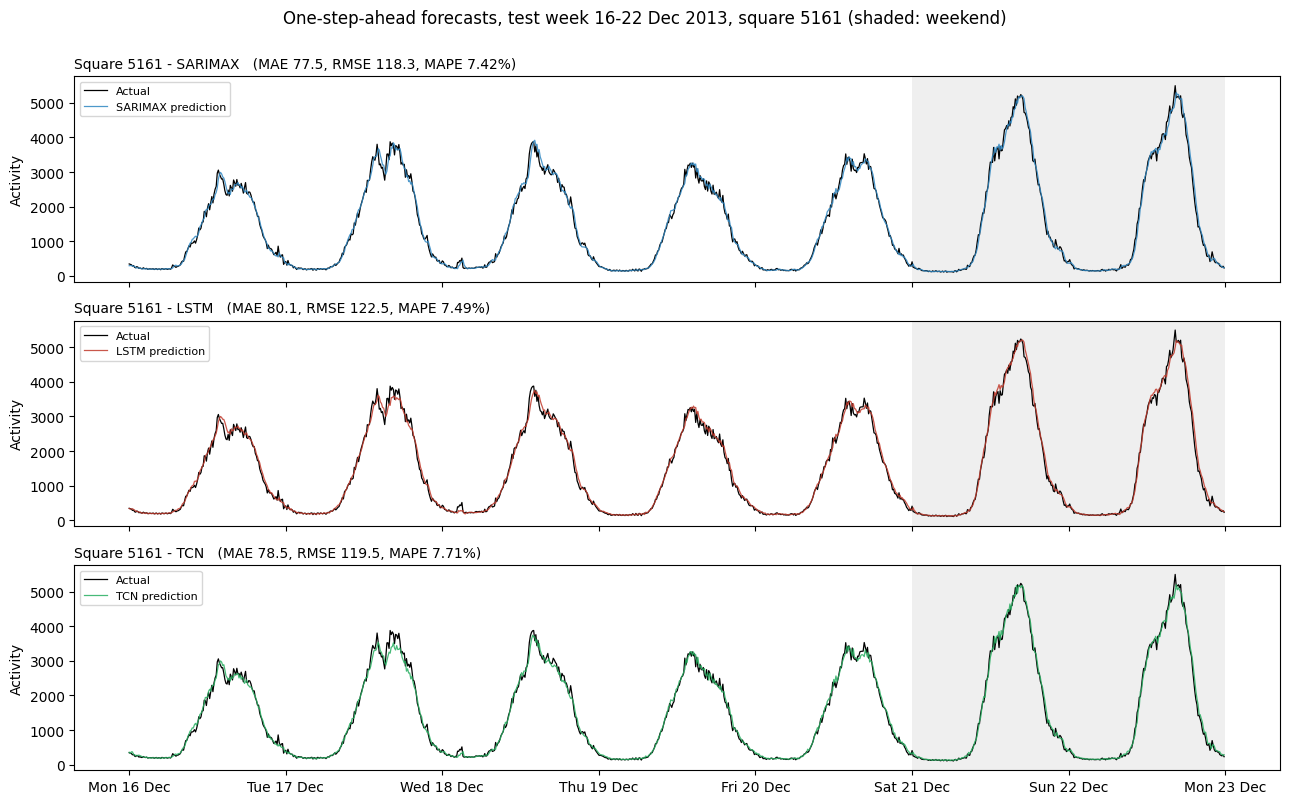

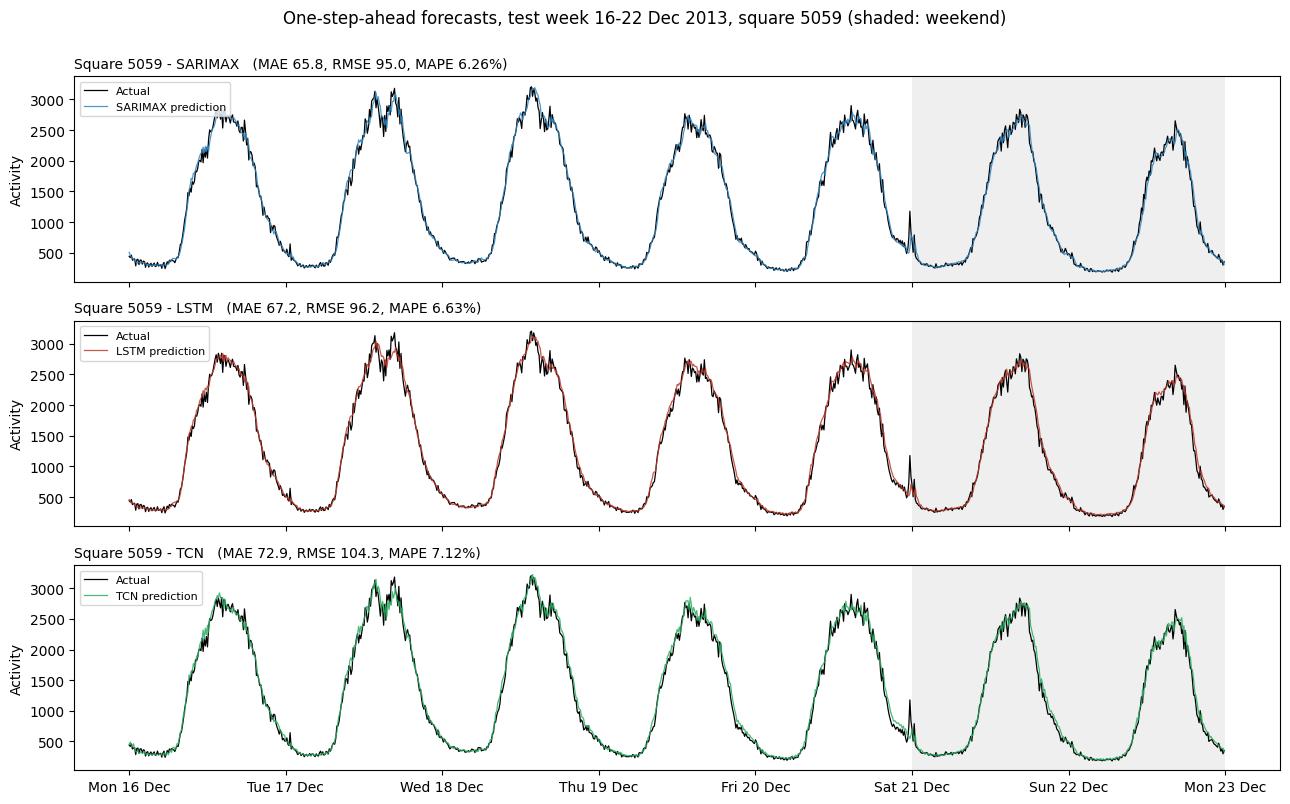

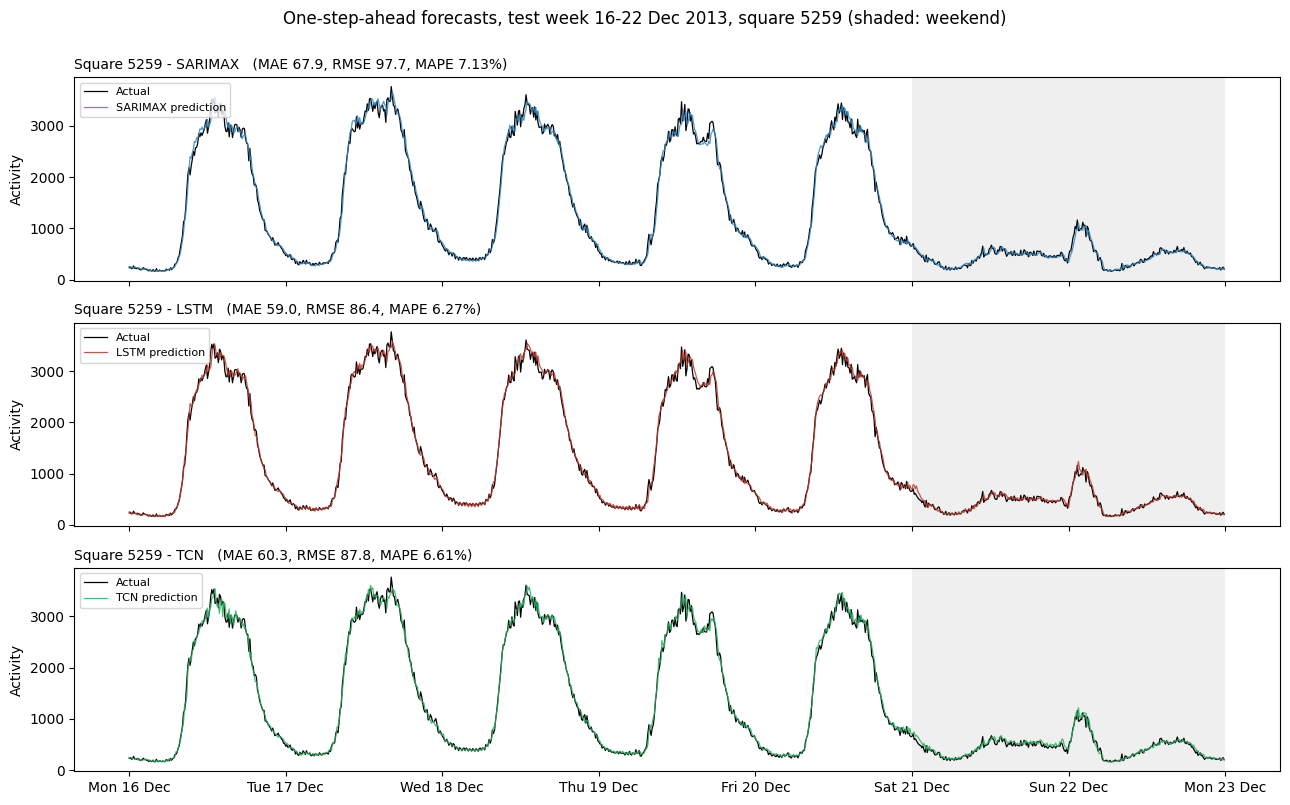

In [8]:
# ---- 7. Nine plots: actual vs predicted, per model and area -------------------------------------
for n, sq in enumerate(TOP3):
    p = load_preds(sq)
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, sharey=True)
    for ax, m in zip(axes, MODELS):
        mt = TABLES[sq].loc[m]
        ax.plot(p.index, p['actual'], color='black', lw=0.9, label='Actual')
        ax.plot(p.index, p[m], color=COLORS[m], lw=0.9, alpha=0.85, label=f'{m} prediction')
        ax.set_title(f"Square {sq} - {m}   (MAE {mt['MAE']:.1f}, RMSE {mt['RMSE']:.1f}, MAPE {mt['MAPE_%']:.2f}%)",
                     loc='left', fontsize=10)
        ax.set_ylabel('Activity'); ax.legend(loc='upper left', fontsize=8)
        for dday in pd.date_range('2013-12-21', '2013-12-22'):
            ax.axvspan(dday, dday + pd.Timedelta(days=1), color='grey', alpha=0.12, lw=0)
    axes[-1].xaxis.set_major_locator(mdates.DayLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
    fig.suptitle(f'One-step-ahead forecasts, test week 16-22 Dec 2013, square {sq} (shaded: weekend)', y=1.0)
    fig.tight_layout(); fig.savefig(FIG_DIR / f'fig{7 + n:02d}_predictions_{sq}.png', dpi=200, bbox_inches='tight'); plt.show()

In [9]:
# ---- 8. Training / execution time --------------------------------------------------------------
timing = pd.read_csv(TIMING_PATH)
timing = timing[timing['square'].isin(TOP3)]
print('Per area:'); print(timing.round(3).to_string(index=False))
avg = timing.groupby('model')[['train_s', 'epochs', 'n_params', 'infer_total_s', 'infer_ms_per_step']].agg(['mean', 'std'])
avg.to_csv(RES_DIR / 'timing_summary.csv')
print('\nMean ± std across the three areas:'); print(avg.round(3).to_string())
print('\nHardware:', HARDWARE)
print('SARIMAX runs on CPU (statsmodels); LSTM/TCN on', HARDWARE['gpu'])

Per area:
 square   model  train_s  epochs  best_epoch  n_params  infer_total_s  infer_ms_per_step
   5161 SARIMAX   88.362     NaN         NaN        24          0.163              0.162
   5161    LSTM   13.166    33.0        27.0     69249          0.122              0.121
   5161     TCN   39.694    26.0        20.0     37505          0.085              0.084
   5059 SARIMAX   88.683     NaN         NaN        24          0.070              0.069
   5059    LSTM   11.221    25.0        19.0     69249          0.064              0.063
   5059     TCN   46.029    35.0        29.0     37505          0.131              0.130
   5259 SARIMAX   89.974     NaN         NaN        24          0.149              0.148
   5259    LSTM   20.254    50.0        44.0     69249          0.064              0.064
   5259     TCN   57.790    48.0        42.0     37505          0.099              0.098

Mean ± std across the three areas:
        train_s         epochs         n_params      infer_total

## Failure analysis: where and when do the models fail?
Errors by hour of day show whether the models fail at peaks, ramps, or at night (where MAPE inflates).
Daily errors locate the worst period, which is then shown in detail.

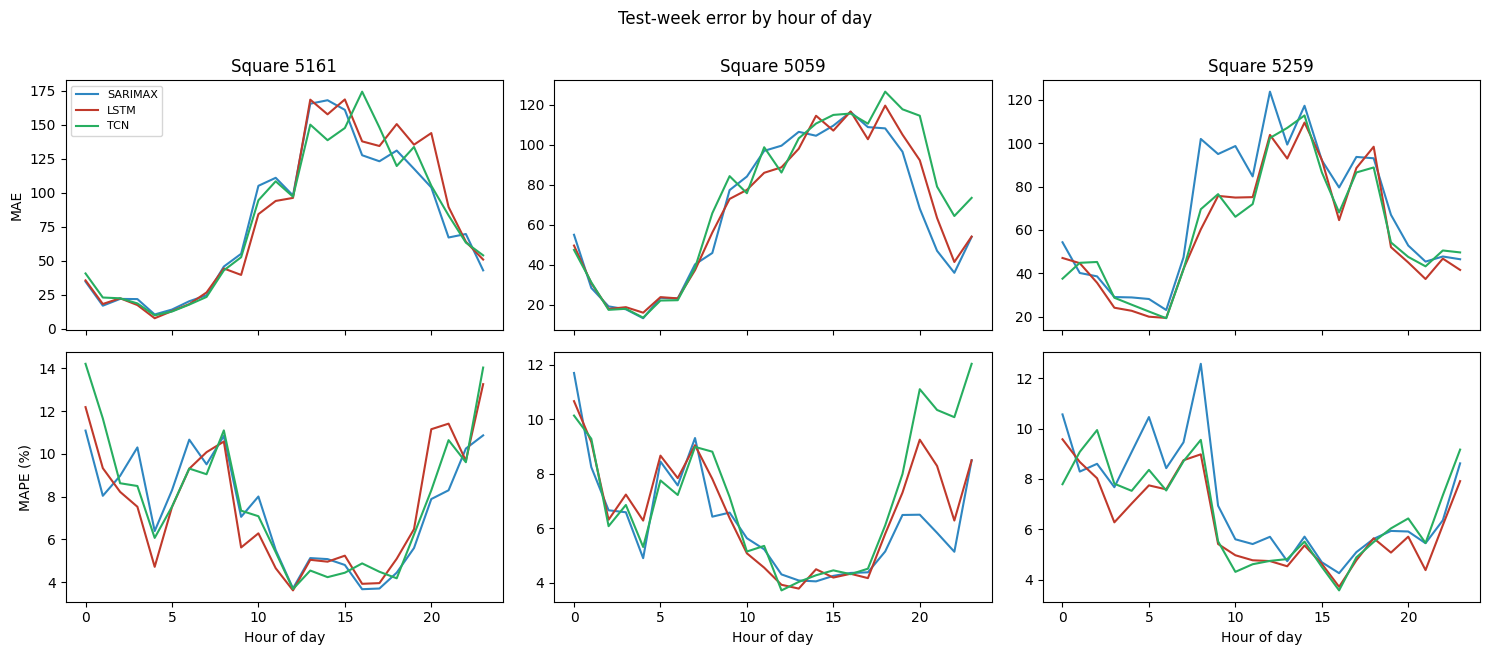

Daily WAPE (%) per model:
model              LSTM  SARIMAX    TCN
square day                             
5059   2013-12-16  4.48     5.06   4.85
       2013-12-17  5.56     5.81   5.81
       2013-12-18  4.35     4.02   5.14
       2013-12-19  4.95     4.59   5.90
       2013-12-20  6.34     5.77   6.60
       2013-12-21  5.40     5.29   5.92
       2013-12-22  6.51     6.13   6.42
5161   2013-12-16  5.81     5.67   5.82
       2013-12-17  5.91     5.58   6.62
       2013-12-18  6.02     5.92   5.61
       2013-12-19  5.41     5.19   5.36
       2013-12-20  5.32     4.94   5.23
       2013-12-21  4.88     4.76   4.61
       2013-12-22  5.58     5.58   5.02
5259   2013-12-16  4.01     5.02   4.31
       2013-12-17  3.88     4.64   4.13
       2013-12-18  3.69     4.77   3.51
       2013-12-19  4.98     5.34   4.57
       2013-12-20  4.57     5.09   4.81
       2013-12-21  9.55     8.97  10.60
       2013-12-22  7.99     9.07   8.34


In [10]:
# ---- 9. Error by hour of day and by day ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), sharex=True)
daily_rows = []
for j, sq in enumerate(TOP3):
    p = load_preds(sq)
    for m in MODELS:
        ae = (p[m] - p['actual']).abs(); ape = 100 * ae / p['actual']
        axes[0, j].plot(ae.groupby(p.index.hour).mean(), color=COLORS[m], label=m)
        axes[1, j].plot(ape.groupby(p.index.hour).mean(), color=COLORS[m], label=m)
        for day, g in p.groupby(p.index.date):
            daily_rows.append({'square': sq, 'model': m, 'day': str(day), **metrics(g['actual'], g[m])})
    axes[0, j].set_title(f'Square {sq}'); axes[1, j].set_xlabel('Hour of day')
axes[0, 0].set_ylabel('MAE'); axes[1, 0].set_ylabel('MAPE (%)'); axes[0, 0].legend(fontsize=8)
fig.suptitle('Test-week error by hour of day', y=1.0); fig.tight_layout()
fig.savefig(FIG_DIR / 'fig10_error_by_hour.png', dpi=200, bbox_inches='tight'); plt.show()

daily = pd.DataFrame(daily_rows); daily.to_csv(RES_DIR / 'error_by_day.csv', index=False)
piv = daily.pivot_table(index=['square', 'day'], columns='model', values='WAPE_%')
print('Daily WAPE (%) per model:'); print(piv.round(2).to_string())

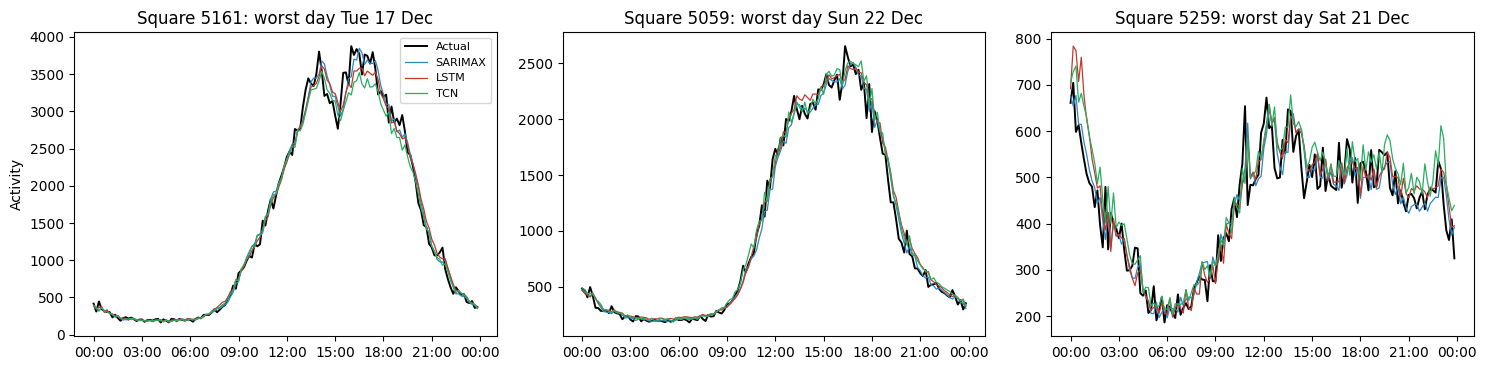

Worst days: {5161: '2013-12-17', 5059: '2013-12-22', 5259: '2013-12-21'}


In [11]:
# ---- 10. Zoom on the worst day (highest mean WAPE across models) for each area --------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
worst = {}
for ax, sq in zip(axes, TOP3):
    wd = daily[daily['square'] == sq].groupby('day')['WAPE_%'].mean().idxmax(); worst[sq] = wd
    p = load_preds(sq)
    g = p[p.index.normalize() == pd.Timestamp(wd)]
    ax.plot(g.index, g['actual'], color='black', lw=1.4, label='Actual')
    for m in MODELS:
        ax.plot(g.index, g[m], color=COLORS[m], lw=0.9, label=m)
    ax.set_title(f'Square {sq}: worst day {pd.Timestamp(wd):%a %d %b}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[0].legend(fontsize=8); axes[0].set_ylabel('Activity')
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig11_worst_day.png', dpi=200, bbox_inches='tight'); plt.show()
print('Worst days:', worst)

## squares 4159 and 4556 (contrasting traffic profiles)


In [12]:
# ---- 11. Optional extra areas --------------------------------------------------------------------
RUN_EXTRA = True
if RUN_EXTRA:
    for sq in EXTRA:
        run_all(sq)
    for sq in EXTRA:
        p = load_preds(sq)
        t = pd.DataFrame({m: metrics(p['actual'], p[m]) for m in MODELS + BASELINES}).T
        t.to_csv(RES_DIR / f'metrics_{sq}.csv'); TABLES[sq] = t
        print(f'\nSquare {sq}'); print(t.round(2).to_string())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


4159 SARIMAX: train 114.6s, test RMSE 19.0
4159 LSTM: train 13.9s, test RMSE 21.5
4159 TCN: train 38.7s, test RMSE 20.7


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


4556 SARIMAX: train 107.8s, test RMSE 34.2


4556 LSTM: train 16.1s, test RMSE 37.3


4556 TCN: train 42.0s, test RMSE 36.6

Square 4159
                           MAE   RMSE  MAPE_%  WAPE_%
SARIMAX                  13.84  18.96    6.01    5.70
LSTM                     15.45  21.49    6.56    6.36
TCN                      15.20  20.73    6.60    6.26
Persistence              15.95  21.54    6.98    6.57
Seasonal naive (1 week)  73.41  97.38   27.96   30.23

Square 4556
                           MAE    RMSE  MAPE_%  WAPE_%
SARIMAX                  25.07   34.23    5.67    5.52
LSTM                     27.99   37.27    6.38    6.16
TCN                      27.54   36.55    6.25    6.07
Persistence              28.86   39.62    6.60    6.36
Seasonal naive (1 week)  96.39  125.86   21.69   21.24


In [13]:
# ---- 12. Summary for the report (upload results_summary.json + new figures to the chat) ------------
summary = {'hardware': HARDWARE, 'best_configs': BEST, 'tuning_decisions': DECISIONS,
           'metrics': {str(sq): t.round(4).to_dict('index') for sq, t in TABLES.items()},
           'timing_mean': json.loads(avg.round(4).to_json()),
           'worst_days': {str(k): v for k, v in worst.items()},
           'daily_wape': {f'{a}|{b}': r for (a, b), r in piv.round(3).to_dict('index').items()},
           'n_logged_runs': len(LOG)}
if 'TCN' in BEST: summary['tcn_receptive_field'] = receptive_field(BEST['TCN'])
summary['timing_per_area'] = timing.round(4).to_dict('records')
if RESID_CSV.exists():
    summary['residual_experiment'] = pd.read_csv(RESID_CSV).round(4).to_dict('records')
bk = RES_DIR / 'direct_target_backup'
if bk.exists():
    summary['direct_target_test_metrics'] = {}
    for sq in TOP3:
        if (bk / f'preds_{sq}.csv').exists():
            p = pd.read_csv(bk / f'preds_{sq}.csv', index_col=0)
            summary['direct_target_test_metrics'][str(sq)] = {m: metrics(p['actual'], p[m]) for m in MODELS + BASELINES}
(RES_DIR / 'results_summary.json').write_text(json.dumps(summary, indent=1, default=str))
print('Saved', RES_DIR / 'results_summary.json')

Saved /content/drive/MyDrive/milan_forecasting/results/results_summary.json
